# Hibrit Model - Route 502

Bu notebook, baseline ve deep learning modellerinin ustune hibrit yaklasimlar ekler.

**Bilesenler:**
1. **Selective Trend** — Az verili saat-gun kombinasyonlari icin lineer trend bileşeni
2. **Deviation History** — Son N seferdeki ortalama sapma (ozgun katki)
3. **Stacking Ensemble** — LSTM + XGBoost tahminlerini meta-model ile birlestirme
4. **SHAP Analizi** — Feature importance kaniti

**Ozgun Katkilar:**
- `scheduled_travel_time` feature'i (makale kullanmiyor)
- Deviation history (gecmis sapma bilgisi)
- Hava durumu + GTFS entegrasyonu

**Referans:** Kaya & Kalay, IEEE Access 2025 — MAE: 2.97 dk, MAPE: 14.79%, R²: 0.9272

In [1]:
import pandas as pd
import numpy as np
import os, sys, warnings, pickle
warnings.filterwarnings('ignore')
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost bulunamadi - XGBoost adimi atlanacak')

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('shap bulunamadi - SHAP analizi atlanacak (pip install shap)')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
FEATURES_CSV = os.path.join(PROJECT_ROOT, 'collected_data', 'route_502_features_v2.csv')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'tables'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)

print(f'TensorFlow: {tf.__version__}')

shap bulunamadi - SHAP analizi atlanacak (pip install shap)
TensorFlow: 2.21.0


## 1. Veri Yukleme ve Gelismis Feature Engineering

In [2]:
df = pd.read_csv(FEATURES_CSV)
print(f'Dataset (v2): {len(df)} satir, {len(df.columns)} kolon')

# --- v2 -> eski sema uyum katmani ---
# v2 farkli kolon isimleri kullaniyor; alt kodu degistirmemek icin map'liyoruz.
df = df.rename(columns={
    'travel_time_min': 'travel_minutes',
    'scheduled_travel_min': 'scheduled_travel_minutes',
})
# is_weekend: v2'de day_type (0=hafta ici, 1=hafta sonu)
df['is_weekend'] = df['day_type'].astype(int)
# deviation_minutes: v2'de tek seferlik kolon yok; gercek - planli'dan hesaplaniyor
df['deviation_minutes'] = df['travel_minutes'] - df['scheduled_travel_minutes']
# weather_category: v2'de sadece sayisal versiyon var; string'e cevir
_w_map = {0: 'clear', 1: 'cloudy', 2: 'rainy', 3: 'snowy'}
df['weather_category'] = df['weather_cat_enc'].map(_w_map).fillna('clear')
# is_rainy: rainy kategorisinden tureyen 0/1
df['is_rainy'] = (df['weather_cat_enc'] == 2).astype(int)
# time_block v2'de int (0..3); LabelEncoder string bekliyor, basit string'e cevir
_tb_map = {0: 'morning_peak', 1: 'off_peak', 2: 'evening_peak', 3: 'night'}
if pd.api.types.is_numeric_dtype(df['time_block']):
    df['time_block'] = df['time_block'].map(_tb_map).fillna('off_peak')
print(f'v2 -> eski sema uyumu uygulandi. Yeni kolon sayisi: {len(df.columns)}')

# Kategorik -> sayisal
le_tb = LabelEncoder()
df['time_block_enc'] = le_tb.fit_transform(df['time_block'])
le_wc = LabelEncoder()
df['weather_enc'] = le_wc.fit_transform(df['weather_category'].fillna('clear'))

# --- Gelismis Feature Engineering ---

# 1. Deviation History: Her (yon, from_stop_seq) icin onceki seferlerin ortalama sapmasi
# Kronolojik sirada, expanding mean (gelecek bilgisi kacagi yok)
df = df.sort_values(['date', 'trip_start_time']).reset_index(drop=True)

df['deviation_history'] = (
    df.groupby(['yon', 'from_stop_seq'])['deviation_minutes']
    .transform(lambda x: x.expanding().mean().shift(1))
)
# Ilk deger icin genel ortalama
df['deviation_history'] = df['deviation_history'].fillna(df['deviation_minutes'].mean())

# 2. Segment ortalama hizi (km/h) - mesafe / sure
df['avg_speed_kmh'] = np.where(
    df['travel_minutes'] > 0,
    (df['distance_m'] / 1000) / (df['travel_minutes'] / 60),
    0
)

# 3. (eski 'schedule_ratio' = travel/scheduled target leakage idi; cikarildi)

# 4. Saat bazli sin/cos encoding (zaten v2'de var ama ayni isimle yeniden uretmek zararsiz)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

print(f'Yeni ozellikler eklendi:')
print(f'  deviation_history: mean={df["deviation_history"].mean():.4f}, std={df["deviation_history"].std():.4f}')
print(f'  avg_speed_kmh: mean={df["avg_speed_kmh"].mean():.2f}, std={df["avg_speed_kmh"].std():.2f}')

Dataset (v2): 138282 satir, 32 kolon
v2 -> eski sema uyumu uygulandi. Yeni kolon sayisi: 36
Yeni ozellikler eklendi:
  deviation_history: mean=0.0636, std=0.7819
  avg_speed_kmh: mean=18.08, std=12.59


## 2. Selective Trend Mekanizmasi

Az verili saat-gun kombinasyonlari icin lineer trend bileşeni.
Ornegín Pazar gecesi 03:00 gibi nadir zamanlar icin yeterli veri yoksa,
GTFS scheduled time + lineer trend ile tahmin yapilir.

**Mantik:**
- Her (time_block, is_weekend, yon) grubu icin ornek sayisini hesapla
- N < esik olan gruplar icin: `trend_prediction = scheduled + alpha * deviation_trend`
- N >= esik olan gruplar icin: ML model tahmini kullanilir

In [3]:
class SelectiveTrend:
    """
    Az verili kombinasyonlar icin trend-bazli tahmin.
    Cok verili kombinasyonlar icin ML model tahmini kullanilir.
    """
    def __init__(self, min_samples=10):
        self.min_samples = min_samples
        self.trend_params = {}  # (time_block, is_weekend, yon) -> (mean_deviation, count)
        self.global_mean_dev = 0
    
    def fit(self, df):
        """Grup bazinda ortalama sapmayi hesapla."""
        self.global_mean_dev = df['deviation_minutes'].mean()
        
        groups = df.groupby(['time_block', 'is_weekend', 'yon'])
        for key, group in groups:
            self.trend_params[key] = {
                'mean_deviation': group['deviation_minutes'].mean(),
                'count': len(group),
            }
        
        sparse = sum(1 for v in self.trend_params.values() if v['count'] < self.min_samples)
        print(f'Selective Trend: {len(self.trend_params)} grup, {sparse} tanesi az verili (N < {self.min_samples})')
        return self
    
    def predict_trend(self, row):
        """Tek satir icin trend tahmini uret."""
        key = (row['time_block'], row['is_weekend'], row['yon'])
        params = self.trend_params.get(key)
        
        if params is None or params['count'] < self.min_samples:
            # Az veri: scheduled + global sapma
            deviation = self.global_mean_dev
        else:
            # Yeterli veri: grup sapmasi
            deviation = params['mean_deviation']
        
        return row['scheduled_travel_minutes'] + deviation
    
    def predict(self, df):
        """Tum dataframe icin trend tahmini."""
        return df.apply(self.predict_trend, axis=1).values
    
    def is_sparse(self, row):
        """Bu kombinasyon az verili mi?"""
        key = (row['time_block'], row['is_weekend'], row['yon'])
        params = self.trend_params.get(key)
        return params is None or params['count'] < self.min_samples


# Kronolojik bolme
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()
print(f'Train: {len(df_train)}, Test: {len(df_test)}')

# Selective trend fit
trend = SelectiveTrend(min_samples=10)
trend.fit(df_train)

# Trend tahminleri
y_train = df_train['travel_minutes'].values
y_test = df_test['travel_minutes'].values
y_pred_trend = trend.predict(df_test)

# Selective trend performansi
mae_trend = mean_absolute_error(y_test, y_pred_trend)
print(f'\nSelective Trend MAE: {mae_trend:.4f} dk')

Train: 110625, Test: 27657
Selective Trend: 16 grup, 0 tanesi az verili (N < 10)

Selective Trend MAE: 0.6216 dk


## 3. Gelismis XGBoost (Ek Feature'lar ile)

Deviation history, schedule ratio, hour sin/cos gibi yeni ozelliklerle
guclendirilmis XGBoost modeli.

In [4]:
# Genisletilmis ozellik seti
# NOT: schedule_ratio = travel_minutes / scheduled_travel_minutes target leakage
# yapiyor (hedef degiskenini doğrudan iceriyor); cikarildi.
ENHANCED_FEATURES = [
    'hour', 'day_of_week', 'is_weekend', 'time_block_enc',
    'from_stop_seq', 'stop_progress', 'distance_m',
    'scheduled_travel_minutes', 'deviation_history',
    'hour_sin', 'hour_cos',
    'temperature', 'humidity', 'precipitation', 'is_rainy', 'weather_enc',
]

TARGET = 'travel_minutes'

X_train = df_train[ENHANCED_FEATURES].values
X_test = df_test[ENHANCED_FEATURES].values

print(f'Genisletilmis ozellik seti: {len(ENHANCED_FEATURES)} ozellik')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

# --- Gelismis XGBoost ---
if HAS_XGB:
    xgb_enhanced = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
    )
    xgb_enhanced.fit(X_train, y_train)
    y_pred_xgb = xgb_enhanced.predict(X_test)
    y_pred_xgb = np.clip(y_pred_xgb, 0, None)
    
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    print(f'\nGelismis XGBoost MAE: {mae_xgb:.4f} dk')
else:
    # XGBoost yoksa Random Forest kullan
    rf_enhanced = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
    rf_enhanced.fit(X_train, y_train)
    y_pred_xgb = rf_enhanced.predict(X_test)
    y_pred_xgb = np.clip(y_pred_xgb, 0, None)
    
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    print(f'\nGelismis Random Forest MAE: {mae_xgb:.4f} dk (XGBoost yerine)')

Genisletilmis ozellik seti: 16 ozellik
X_train: (110625, 16), X_test: (27657, 16)

Gelismis XGBoost MAE: 0.5064 dk


## 4. LSTM Tahminleri (Onceden Egitilmis Model)

`deep_learning.ipynb`'de egitilen LSTM modelini yukleyip test seti icin tahmin uretiyoruz.
Eger model yoksa, burada yeniden egitiyoruz.

In [5]:
SEQUENCE_FEATURES = [
    'travel_minutes', 'scheduled_travel_minutes', 'deviation_minutes',
    'distance_m', 'stop_progress',
]
CONTEXT_FEATURES = [
    'hour', 'day_of_week', 'is_weekend', 'time_block_enc',
    'temperature', 'humidity', 'precipitation', 'is_rainy', 'weather_enc',
]

def create_sequences(df, window_size=3):
    """Trip bazinda sliding window olustur."""
    X_seq_list, X_ctx_list, y_list, idx_list = [], [], [], []
    trip_groups = df.groupby(['bus_id', 'yon', 'trip_start_time'])
    for _, trip in trip_groups:
        trip = trip.sort_values('from_stop_seq', ascending=False)
        if len(trip) < window_size + 1:
            continue
        seq_vals = trip[SEQUENCE_FEATURES].values
        ctx_vals = trip[CONTEXT_FEATURES].values
        target_vals = trip['travel_minutes'].values
        indices = trip.index.values
        for i in range(window_size, len(trip)):
            X_seq_list.append(seq_vals[i - window_size:i])
            X_ctx_list.append(ctx_vals[i])
            y_list.append(target_vals[i])
            idx_list.append(indices[i])
    if not X_seq_list:
        return np.array([]), np.array([]), np.array([]), np.array([])
    return np.array(X_seq_list), np.array(X_ctx_list), np.array(y_list), np.array(idx_list)

# Window size secimi
WINDOW_SIZE = 3
test_y = create_sequences(df, 3)[2]
if len(test_y) < 5:
    WINDOW_SIZE = 2

X_seq_all, X_ctx_all, y_seq_all, idx_all = create_sequences(df, WINDOW_SIZE)
print(f'Window={WINDOW_SIZE}: {len(y_seq_all)} sequence ornegi')

# Train/test: idx_all'daki satirlarin df'teki pozisyonuna gore bol
seq_train_mask = idx_all < split_idx
seq_test_mask = idx_all >= split_idx

X_seq_train = X_seq_all[seq_train_mask]
X_ctx_train_seq = X_ctx_all[seq_train_mask]
y_seq_train = y_seq_all[seq_train_mask]

X_seq_test = X_seq_all[seq_test_mask]
X_ctx_test_seq = X_ctx_all[seq_test_mask]
y_seq_test = y_seq_all[seq_test_mask]
idx_test_seq = idx_all[seq_test_mask]

print(f'LSTM train: {len(y_seq_train)}, test: {len(y_seq_test)}')

# Normalizasyon
if len(X_seq_train) > 0:
    n_seq_feats = X_seq_train.shape[2]
    scaler_seq = MinMaxScaler()
    scaler_seq.fit(X_seq_train.reshape(-1, n_seq_feats))
    X_seq_train_norm = scaler_seq.transform(
        X_seq_train.reshape(-1, n_seq_feats)
    ).reshape(X_seq_train.shape)
    
    scaler_ctx_seq = MinMaxScaler()
    X_ctx_train_norm = scaler_ctx_seq.fit_transform(X_ctx_train_seq)
    
    if len(X_seq_test) > 0:
        X_seq_test_norm = scaler_seq.transform(
            X_seq_test.reshape(-1, n_seq_feats)
        ).reshape(X_seq_test.shape)
        X_ctx_test_norm = scaler_ctx_seq.transform(X_ctx_test_seq)
    
    print('Normalizasyon tamamlandi')

Window=3: 97483 sequence ornegi
LSTM train: 77757, test: 19726
Normalizasyon tamamlandi


In [6]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm(window_size, n_seq_feats, n_ctx_feats, units=128, dropout=0.2):
    seq_input = Input(shape=(window_size, n_seq_feats), name='seq_input')
    rnn_out = LSTM(units, return_sequences=False)(seq_input)
    rnn_out = Dropout(dropout)(rnn_out)
    ctx_input = Input(shape=(n_ctx_feats,), name='ctx_input')
    ctx_dense = Dense(32, activation='relu')(ctx_input)
    ctx_dense = Dropout(dropout)(ctx_dense)
    merged = tf.keras.layers.concatenate([rnn_out, ctx_dense])
    dense1 = Dense(64, activation='relu')(merged)
    dense1 = Dropout(dropout)(dense1)
    output = Dense(1, activation='linear')(dense1)
    model = Model(inputs=[seq_input, ctx_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mae', metrics=['mae'])
    return model

# LSTM egit (hibrit icin taze egitim — ayni split ile)
y_pred_lstm_test = np.full(len(y_test), np.nan)

if len(y_seq_train) >= 3 and len(y_seq_test) >= 1:
    lstm_model = build_lstm(WINDOW_SIZE, n_seq_feats, len(CONTEXT_FEATURES))
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    lstm_model.fit(
        [X_seq_train_norm, X_ctx_train_norm], y_seq_train,
        epochs=100, batch_size=min(16, len(y_seq_train)),
        validation_data=([X_seq_test_norm, X_ctx_test_norm], y_seq_test),
        callbacks=[early_stop], verbose=0
    )
    
    y_pred_lstm_seq = lstm_model.predict([X_seq_test_norm, X_ctx_test_norm], verbose=0).flatten()
    y_pred_lstm_seq = np.clip(y_pred_lstm_seq, 0, None)
    
    # LSTM tahminlerini df_test satirlarina esle
    for i, df_idx in enumerate(idx_test_seq):
        test_pos = df_idx - split_idx
        if 0 <= test_pos < len(y_test):
            y_pred_lstm_test[test_pos] = y_pred_lstm_seq[i]
    
    lstm_coverage = np.sum(~np.isnan(y_pred_lstm_test))
    print(f'LSTM tahminleri: {lstm_coverage}/{len(y_test)} test ornegini kapsiyor')
    
    valid_lstm = ~np.isnan(y_pred_lstm_test)
    if valid_lstm.sum() > 0:
        mae_lstm = mean_absolute_error(y_test[valid_lstm], y_pred_lstm_test[valid_lstm])
        print(f'LSTM MAE (kapsiyor): {mae_lstm:.4f} dk')
else:
    print('Yetersiz sequence verisi — LSTM atlanacak, sadece XGBoost + Trend kullanilacak')

LSTM tahminleri: 19726/27657 test ornegini kapsiyor
LSTM MAE (kapsiyor): 0.3653 dk


## 5. Stacking Ensemble (Hibrit Model)

**Yaklasim:** Farkli modellerin tahminlerini bir meta-model ile birlestir.

```
Level-0 (Base modeller):
  - XGBoost tahminleri (tum test ornekleri)
  - LSTM tahminleri (sequence ornekleri)
  - Selective Trend tahminleri (tum test ornekleri)

Level-1 (Meta-model):
  - Ridge Regression: [xgb_pred, lstm_pred, trend_pred] → final_pred
```

LSTM sadece bazi ornekleri kapsar (sliding window gerektiriyor).
Kapsanmayan orneklerde LSTM yerine trend kullanilir.

In [7]:
# --- Stacking Ensemble ---

# LSTM'in kapsamadigi ornekler icin trend tahminini kullan
y_pred_lstm_filled = y_pred_lstm_test.copy()
nan_mask = np.isnan(y_pred_lstm_filled)
y_pred_lstm_filled[nan_mask] = y_pred_trend[nan_mask]

# Level-0 tahminlerini birlesitir
stack_train_preds = np.column_stack([
    # Train icin base model tahminleri (cross-prediction)
    # Basit yaklasim: train setinde de ayni modelleri kullan
    xgb_enhanced.predict(X_train) if HAS_XGB else rf_enhanced.predict(X_train),
    trend.predict(df_train),
])

stack_test_preds = np.column_stack([
    y_pred_xgb,
    y_pred_trend,
])

# LSTM tahminlerini de ekle (eger varsa)
has_lstm = np.sum(~np.isnan(y_pred_lstm_test)) > 0
if has_lstm:
    # Train icin LSTM tahminleri
    lstm_train_preds = np.full(len(y_train), np.nan)
    train_seq_mask = idx_all < split_idx
    if train_seq_mask.sum() > 0:
        train_seq_idx = idx_all[train_seq_mask]
        X_seq_tr = X_seq_all[train_seq_mask]
        X_ctx_tr = X_ctx_all[train_seq_mask]
        X_seq_tr_norm = scaler_seq.transform(
            X_seq_tr.reshape(-1, n_seq_feats)
        ).reshape(X_seq_tr.shape)
        X_ctx_tr_norm = scaler_ctx_seq.transform(X_ctx_tr)
        lstm_tr_pred = lstm_model.predict([X_seq_tr_norm, X_ctx_tr_norm], verbose=0).flatten()
        for i, df_idx in enumerate(train_seq_idx):
            if 0 <= df_idx < len(y_train):
                lstm_train_preds[df_idx] = lstm_tr_pred[i]
    
    # NaN'lari trend ile doldur
    train_trend = trend.predict(df_train)
    nan_train = np.isnan(lstm_train_preds)
    lstm_train_preds[nan_train] = train_trend[nan_train]
    
    stack_train_preds = np.column_stack([stack_train_preds, lstm_train_preds])
    stack_test_preds = np.column_stack([stack_test_preds, y_pred_lstm_filled])
    feature_names_meta = ['XGBoost', 'Trend', 'LSTM']
else:
    feature_names_meta = ['XGBoost', 'Trend']

print(f'Stacking giris boyutu: {stack_test_preds.shape[1]} base model')
print(f'  Modeller: {feature_names_meta}')

# Level-1: Ridge meta-model
meta_model = Ridge(alpha=1.0)
meta_model.fit(stack_train_preds, y_train)

y_pred_hybrid = meta_model.predict(stack_test_preds)
y_pred_hybrid = np.clip(y_pred_hybrid, 0, None)

# Meta-model agirliklari
print(f'\nMeta-model agirliklari:')
for name, coef in zip(feature_names_meta, meta_model.coef_):
    print(f'  {name}: {coef:.4f}')
print(f'  Bias: {meta_model.intercept_:.4f}')

Stacking giris boyutu: 3 base model
  Modeller: ['XGBoost', 'Trend', 'LSTM']

Meta-model agirliklari:
  XGBoost: 1.0402
  Trend: -0.1613
  LSTM: 0.2556
  Bias: -0.1330


## 6. Tum Modellerin Karsilastirmasi

In [8]:
def evaluate_model(y_true, y_pred, name):
    """Performans metriklerini hesapla."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return {
        'model': name,
        'MAE (dk)': round(mae, 4),
        'RMSE (dk)': round(rmse, 4),
        'MAPE (%)': round(mape, 2),
        'R2': round(r2, 4),
    }

# Hibrit model sonuclari
hybrid_results = []
hybrid_results.append(evaluate_model(y_test, y_pred_trend, 'Selective Trend'))
hybrid_results.append(evaluate_model(y_test, y_pred_xgb, 'Enhanced XGBoost' if HAS_XGB else 'Enhanced RF'))
hybrid_results.append(evaluate_model(y_test, y_pred_hybrid, 'Hybrid Stacking'))

# Onceki sonuclari yukle
prev_csv = os.path.join(RESULTS_DIR, 'tables', 'all_model_results.csv')
if os.path.exists(prev_csv):
    prev_df = pd.read_csv(prev_csv)
    all_results = pd.concat([prev_df, pd.DataFrame(hybrid_results)], ignore_index=True)
else:
    all_results = pd.DataFrame(hybrid_results)

# Duplikatlari kaldir (ayni model ismi varsa yenisini al)
all_results = all_results.drop_duplicates(subset='model', keep='last')
all_results = all_results.sort_values('MAE (dk)').reset_index(drop=True)

print('=' * 70)
print('TUM MODELLER - KARSILASTIRMA')
print('=' * 70)
print(all_results.to_string(index=False))
print('=' * 70)
print(f'\nMakale: MAE=2.97 dk, MAPE=14.79%, R2=0.9272')

if len(y_test) < 20:
    print(f'\n** Test seti {len(y_test)} ornek — gosterge niteliğinde **')

# Kaydet
hybrid_csv = os.path.join(RESULTS_DIR, 'tables', 'hybrid_results.csv')
pd.DataFrame(hybrid_results).to_csv(hybrid_csv, index=False)

all_csv = os.path.join(RESULTS_DIR, 'tables', 'all_model_results.csv')
all_results.to_csv(all_csv, index=False)
print(f'\nKaydedildi: {all_csv}')

TUM MODELLER - KARSILASTIRMA
                 model  MAE (dk)  RMSE (dk)  MAPE (%)      R2
                  LSTM    0.4138     0.6914     42.11  0.0484
                   GRU    0.4140     0.6887     41.89  0.0558
         Random Forest    0.4695     0.8731     50.22  0.3325
               XGBoost    0.4784     0.8819     52.15  0.3191
       Hybrid Stacking    0.5003     0.9295     54.53  0.2435
      Enhanced XGBoost    0.5064     0.9282     56.14  0.2456
    Historical Average    0.5662     0.9922     62.50  0.1379
     Linear Regression    0.5933     1.0597     64.33  0.0167
Naive (GTFS Scheduled)    0.6125     1.0935     64.99 -0.0470
       Selective Trend    0.6216     1.0938     68.83 -0.0475

Makale: MAE=2.97 dk, MAPE=14.79%, R2=0.9272

Kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\tables\all_model_results.csv


## 7. SHAP Analizi — Feature Importance

XGBoost modeli uzerinde SHAP analizi yaparak hangi ozelliklerin
tahminleri en cok etkiledigini gosteriyoruz.

Bu analiz ozellikle `scheduled_travel_minutes` ve `deviation_history`
ozelliklerinin katkisini kanitlamak icin onemli.

In [9]:
if HAS_SHAP and HAS_XGB:
    explainer = shap.TreeExplainer(xgb_enhanced)
    shap_values = explainer.shap_values(X_test)
    
    # Feature importance sirasi
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_order = np.argsort(mean_abs_shap)[::-1]
    
    print('SHAP Feature Importance (ortalama |SHAP|):')
    print('-' * 45)
    for idx in importance_order:
        print(f'  {ENHANCED_FEATURES[idx]:30s} {mean_abs_shap[idx]:.4f}')
    
    # Scheduled ve deviation katkisi
    sched_idx = ENHANCED_FEATURES.index('scheduled_travel_minutes')
    dev_idx = ENHANCED_FEATURES.index('deviation_history')
    print(f'\n--- Ozgun Katki Analizi ---')
    print(f'scheduled_travel_minutes SHAP: {mean_abs_shap[sched_idx]:.4f} '
          f'(sirada: {list(importance_order).index(sched_idx) + 1})')
    print(f'deviation_history SHAP:        {mean_abs_shap[dev_idx]:.4f} '
          f'(sirada: {list(importance_order).index(dev_idx) + 1})')

elif not HAS_SHAP:
    # SHAP yoksa XGBoost'un kendi feature importance'ini kullan
    print('SHAP kutuphanesi yok — XGBoost feature importance kullaniliyor')
    if HAS_XGB:
        importances = xgb_enhanced.feature_importances_
        order = np.argsort(importances)[::-1]
        print('\nXGBoost Feature Importance (gain):')
        print('-' * 45)
        for idx in order:
            print(f'  {ENHANCED_FEATURES[idx]:30s} {importances[idx]:.4f}')
    else:
        importances = rf_enhanced.feature_importances_
        order = np.argsort(importances)[::-1]
        print('\nRandom Forest Feature Importance:')
        print('-' * 45)
        for idx in order:
            print(f'  {ENHANCED_FEATURES[idx]:30s} {importances[idx]:.4f}')

SHAP kutuphanesi yok — XGBoost feature importance kullaniliyor

XGBoost Feature Importance (gain):
---------------------------------------------
  deviation_history              0.2960
  scheduled_travel_minutes       0.1863
  distance_m                     0.0801
  from_stop_seq                  0.0706
  time_block_enc                 0.0527
  stop_progress                  0.0460
  hour                           0.0342
  hour_cos                       0.0326
  is_weekend                     0.0307
  hour_sin                       0.0269
  humidity                       0.0267
  temperature                    0.0256
  day_of_week                    0.0251
  is_rainy                       0.0229
  weather_enc                    0.0222
  precipitation                  0.0213


## 8. Scheduled Feature Ablation Calismasi

`scheduled_travel_minutes` ve `deviation_history` olmadan modelin
performansinin ne kadar dustugunu gostererek ozgun katkimizi kanitliyoruz.

In [10]:
ablation_results = []

# 1. Tam model (zaten hesaplandi)
ablation_results.append({
    'config': 'Tam Model (tum ozellikler)',
    'MAE (dk)': round(mean_absolute_error(y_test, y_pred_xgb), 4),
    'features': len(ENHANCED_FEATURES),
})

# 2. scheduled_travel_minutes olmadan
features_no_sched = [f for f in ENHANCED_FEATURES if f != 'scheduled_travel_minutes']
if HAS_XGB:
    xgb_no_sched = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                      subsample=0.8, colsample_bytree=0.8, random_state=42)
    xgb_no_sched.fit(df_train[features_no_sched].values, y_train)
    y_no_sched = np.clip(xgb_no_sched.predict(df_test[features_no_sched].values), 0, None)
else:
    rf_no_sched = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
    rf_no_sched.fit(df_train[features_no_sched].values, y_train)
    y_no_sched = np.clip(rf_no_sched.predict(df_test[features_no_sched].values), 0, None)

ablation_results.append({
    'config': 'scheduled_travel_minutes YOK',
    'MAE (dk)': round(mean_absolute_error(y_test, y_no_sched), 4),
    'features': len(features_no_sched),
})

# 3. deviation_history olmadan
features_no_dev = [f for f in ENHANCED_FEATURES if f != 'deviation_history']
if HAS_XGB:
    xgb_no_dev = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8, random_state=42)
    xgb_no_dev.fit(df_train[features_no_dev].values, y_train)
    y_no_dev = np.clip(xgb_no_dev.predict(df_test[features_no_dev].values), 0, None)
else:
    rf_no_dev = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
    rf_no_dev.fit(df_train[features_no_dev].values, y_train)
    y_no_dev = np.clip(rf_no_dev.predict(df_test[features_no_dev].values), 0, None)

ablation_results.append({
    'config': 'deviation_history YOK',
    'MAE (dk)': round(mean_absolute_error(y_test, y_no_dev), 4),
    'features': len(features_no_dev),
})

# 4. Hava durumu olmadan
weather_feats = ['temperature', 'humidity', 'precipitation', 'is_rainy', 'weather_enc']
features_no_weather = [f for f in ENHANCED_FEATURES if f not in weather_feats]
if HAS_XGB:
    xgb_no_w = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42)
    xgb_no_w.fit(df_train[features_no_weather].values, y_train)
    y_no_w = np.clip(xgb_no_w.predict(df_test[features_no_weather].values), 0, None)
else:
    rf_no_w = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
    rf_no_w.fit(df_train[features_no_weather].values, y_train)
    y_no_w = np.clip(rf_no_w.predict(df_test[features_no_weather].values), 0, None)

ablation_results.append({
    'config': 'Hava durumu YOK',
    'MAE (dk)': round(mean_absolute_error(y_test, y_no_w), 4),
    'features': len(features_no_weather),
})

# 5. Ikisi birden yok (scheduled + deviation)
features_no_both = [f for f in ENHANCED_FEATURES 
                     if f not in ['scheduled_travel_minutes', 'deviation_history']]
if HAS_XGB:
    xgb_no_both = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8, random_state=42)
    xgb_no_both.fit(df_train[features_no_both].values, y_train)
    y_no_both = np.clip(xgb_no_both.predict(df_test[features_no_both].values), 0, None)
else:
    rf_no_both = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
    rf_no_both.fit(df_train[features_no_both].values, y_train)
    y_no_both = np.clip(rf_no_both.predict(df_test[features_no_both].values), 0, None)

ablation_results.append({
    'config': 'scheduled + deviation YOK',
    'MAE (dk)': round(mean_absolute_error(y_test, y_no_both), 4),
    'features': len(features_no_both),
})

ablation_df = pd.DataFrame(ablation_results).sort_values('MAE (dk)')
print('\n=== ABLATION CALISMASI ===')
print(ablation_df.to_string(index=False))

# Kaydet
ablation_csv = os.path.join(RESULTS_DIR, 'tables', 'ablation_study.csv')
ablation_df.to_csv(ablation_csv, index=False)
print(f'\nKaydedildi: {ablation_csv}')


=== ABLATION CALISMASI ===
                      config  MAE (dk)  features
             Hava durumu YOK    0.4818        11
  Tam Model (tum ozellikler)    0.5064        16
   scheduled + deviation YOK    0.5186        14
       deviation_history YOK    0.5189        15
scheduled_travel_minutes YOK    0.5206        15

Kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\tables\ablation_study.csv


## 9. Gorsellestirmeler

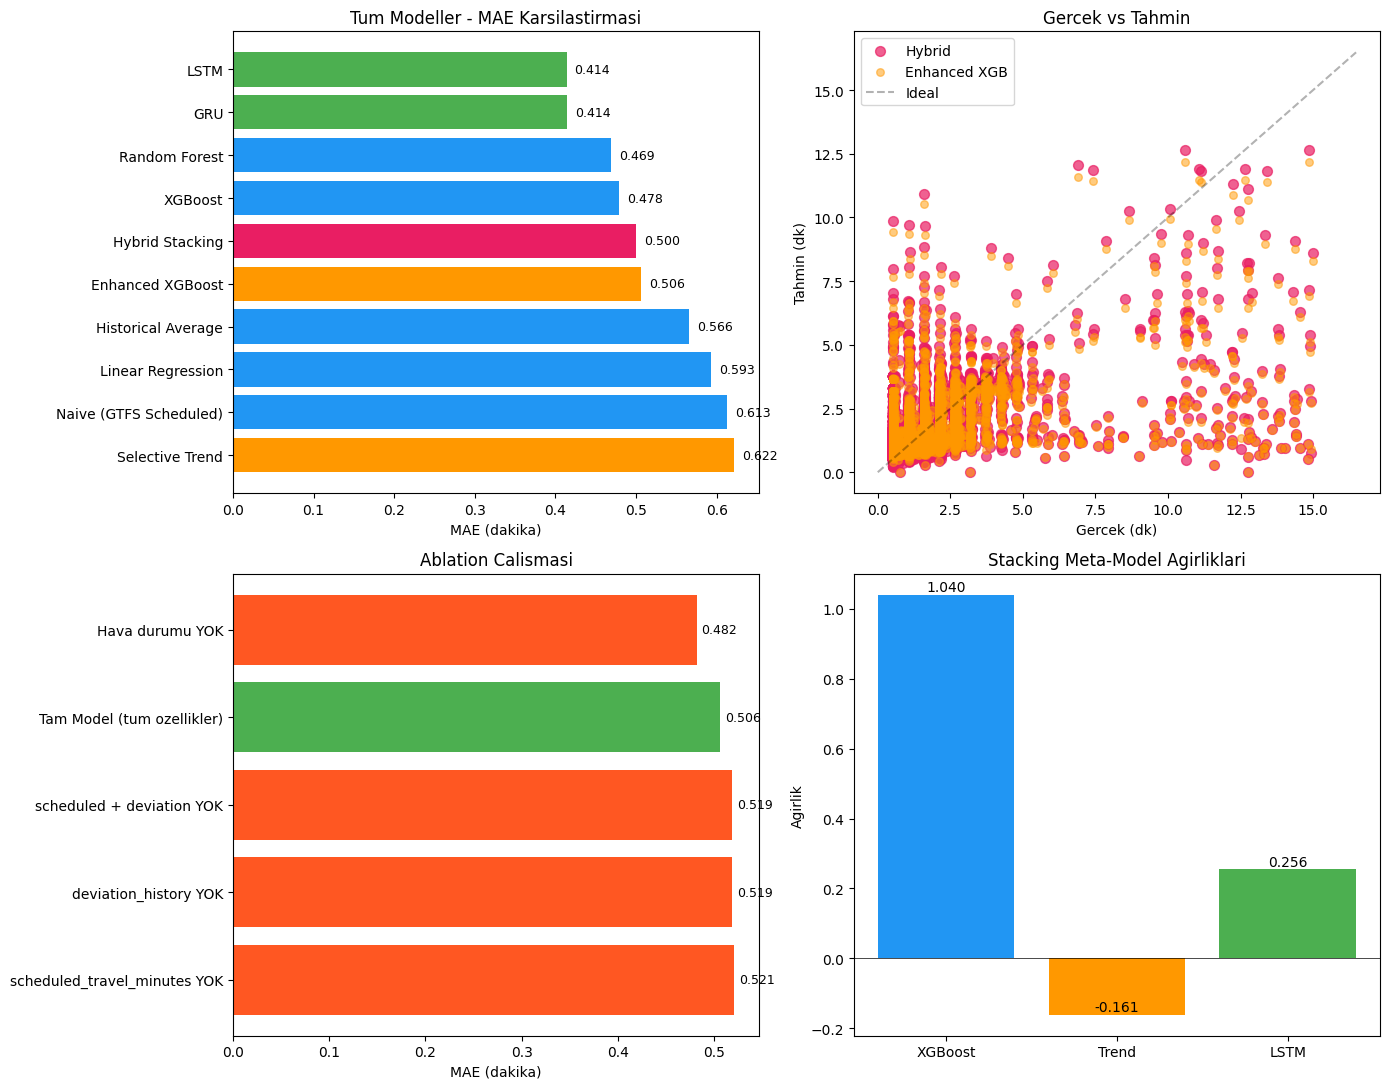

Gorsel kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\figures\hybrid_analysis.png


In [11]:
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False
    print('matplotlib bulunamadi')

if HAS_PLT:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    
    # 1. Tum modeller MAE karsilastirmasi
    colors = []
    for m in all_results['model']:
        if 'Hybrid' in m:
            colors.append('#E91E63')  # Pembe - hibrit
        elif 'Enhanced' in m or 'Selective' in m:
            colors.append('#FF9800')  # Turuncu - bu notebook
        elif 'LSTM' in m or 'GRU' in m:
            colors.append('#4CAF50')  # Yesil - deep learning
        else:
            colors.append('#2196F3')  # Mavi - baseline
    
    axes[0, 0].barh(all_results['model'], all_results['MAE (dk)'], color=colors)
    axes[0, 0].set_xlabel('MAE (dakika)')
    axes[0, 0].set_title('Tum Modeller - MAE Karsilastirmasi')
    axes[0, 0].invert_yaxis()
    for i, v in enumerate(all_results['MAE (dk)']):
        axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
    
    # 2. Gercek vs Tahmin scatter (Hybrid)
    axes[0, 1].scatter(y_test, y_pred_hybrid, alpha=0.7, s=50, c='#E91E63', label='Hybrid')
    axes[0, 1].scatter(y_test, y_pred_xgb, alpha=0.5, s=30, c='#FF9800', label='Enhanced XGB')
    lim = max(y_test.max(), y_pred_hybrid.max()) * 1.1
    axes[0, 1].plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Ideal')
    axes[0, 1].set_xlabel('Gercek (dk)')
    axes[0, 1].set_ylabel('Tahmin (dk)')
    axes[0, 1].set_title('Gercek vs Tahmin')
    axes[0, 1].legend()
    
    # 3. Ablation study bar chart
    ablation_sorted = ablation_df.sort_values('MAE (dk)')
    abl_colors = ['#4CAF50' if 'Tam' in c else '#FF5722' for c in ablation_sorted['config']]
    axes[1, 0].barh(ablation_sorted['config'], ablation_sorted['MAE (dk)'], color=abl_colors)
    axes[1, 0].set_xlabel('MAE (dakika)')
    axes[1, 0].set_title('Ablation Calismasi')
    axes[1, 0].invert_yaxis()
    for i, v in enumerate(ablation_sorted['MAE (dk)']):
        axes[1, 0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
    
    # 4. Meta-model agirliklari
    axes[1, 1].bar(feature_names_meta, meta_model.coef_, color=['#2196F3', '#FF9800', '#4CAF50'][:len(feature_names_meta)])
    axes[1, 1].set_ylabel('Agirlik')
    axes[1, 1].set_title('Stacking Meta-Model Agirliklari')
    axes[1, 1].axhline(y=0, color='black', linewidth=0.5)
    for i, v in enumerate(meta_model.coef_):
        axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, 'figures', 'hybrid_analysis.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gorsel kaydedildi: {fig_path}')

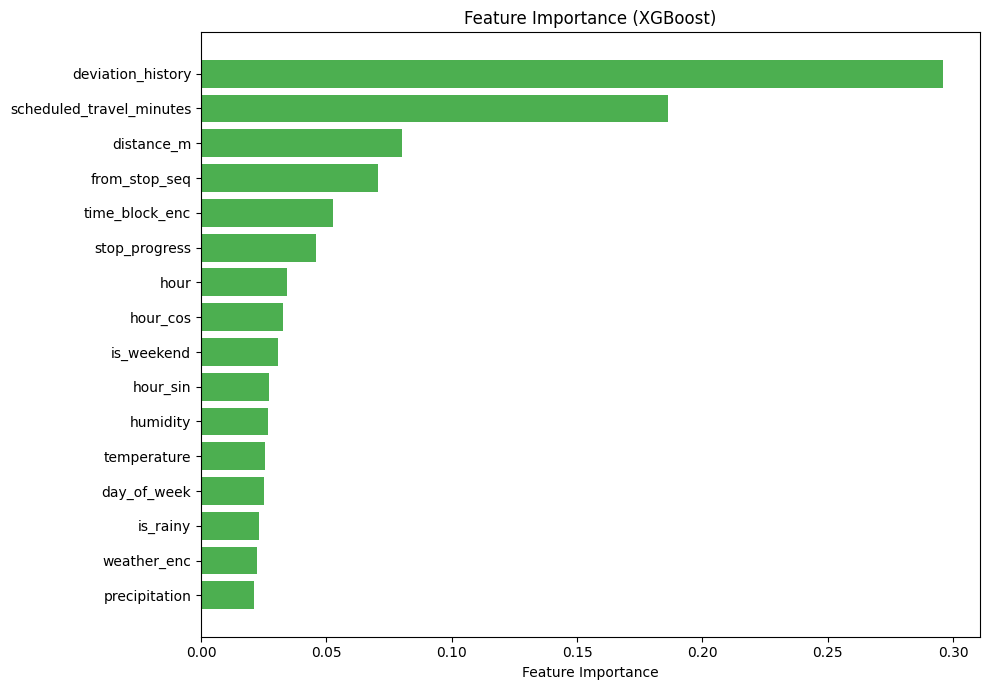

Feature importance gorseli kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\figures\feature_importance_enhanced.png


In [12]:
# SHAP beeswarm plot (eger varsa)
if HAS_SHAP and HAS_XGB and HAS_PLT:
    fig_shap, ax_shap = plt.subplots(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test, feature_names=ENHANCED_FEATURES, show=False)
    plt.tight_layout()
    shap_path = os.path.join(RESULTS_DIR, 'figures', 'shap_summary.png')
    plt.savefig(shap_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'SHAP gorseli kaydedildi: {shap_path}')
elif HAS_PLT:
    # SHAP yoksa feature importance bar chart
    fig_fi, ax_fi = plt.subplots(figsize=(10, 7))
    if HAS_XGB:
        importances = xgb_enhanced.feature_importances_
    else:
        importances = rf_enhanced.feature_importances_
    order = np.argsort(importances)
    ax_fi.barh([ENHANCED_FEATURES[i] for i in order], importances[order], color='#4CAF50')
    ax_fi.set_xlabel('Feature Importance')
    ax_fi.set_title('Feature Importance (XGBoost)' if HAS_XGB else 'Feature Importance (RF)')
    plt.tight_layout()
    fi_path = os.path.join(RESULTS_DIR, 'figures', 'feature_importance_enhanced.png')
    plt.savefig(fi_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Feature importance gorseli kaydedildi: {fi_path}')

## 10. Hibrit Modeli Kaydet

In [13]:
# Hibrit model bilesenleri kaydet
hybrid_path = os.path.join(MODELS_DIR, 'hybrid_model.pkl')
hybrid_bundle = {
    'meta_model': meta_model,
    'selective_trend': trend,
    'enhanced_features': ENHANCED_FEATURES,
    'sequence_features': SEQUENCE_FEATURES,
    'context_features': CONTEXT_FEATURES,
    'window_size': WINDOW_SIZE,
    'feature_names_meta': feature_names_meta,
    'le_time_block': le_tb,
    'le_weather': le_wc,
}

# XGBoost/RF modeli
if HAS_XGB:
    hybrid_bundle['xgb_model'] = xgb_enhanced
else:
    hybrid_bundle['rf_model'] = rf_enhanced

with open(hybrid_path, 'wb') as f:
    pickle.dump(hybrid_bundle, f)
print(f'Hibrit model kaydedildi: {hybrid_path}')

# LSTM modeli ayri kaydet
if has_lstm:
    lstm_hybrid_path = os.path.join(MODELS_DIR, 'lstm_hybrid.keras')
    lstm_model.save(lstm_hybrid_path)
    
    scaler_hybrid_path = os.path.join(MODELS_DIR, 'scalers_hybrid.pkl')
    with open(scaler_hybrid_path, 'wb') as f:
        pickle.dump({'scaler_seq': scaler_seq, 'scaler_ctx': scaler_ctx_seq}, f)
    print(f'LSTM (hibrit) kaydedildi: {lstm_hybrid_path}')
    print(f'Scalers (hibrit) kaydedildi: {scaler_hybrid_path}')

Hibrit model kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\models\hybrid_model.pkl
LSTM (hibrit) kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\models\lstm_hybrid.keras
Scalers (hibrit) kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\models\scalers_hybrid.pkl


## Sonuc

| Cikti | Dosya |
|-------|-------|
| Hibrit model (XGBoost + Trend + Meta) | `models/hybrid_model.pkl` |
| LSTM (hibrit icin) | `models/lstm_hybrid.keras` |
| Scalers (hibrit) | `models/scalers_hybrid.pkl` |
| Hibrit sonuclari | `results/tables/hybrid_results.csv` |
| Tum model karsilastirmasi | `results/tables/all_model_results.csv` |
| Ablation calismasi | `results/tables/ablation_study.csv` |
| Gorseller | `results/figures/hybrid_analysis.png` |
| SHAP / Feature Importance | `results/figures/shap_summary.png` |

**Hibrit Model Bileşenleri:**
1. **Selective Trend** — Az verili (saat, gun, yon) kombinasyonlari icin GTFS + sapma trendi
2. **Enhanced XGBoost** — 17 ozellik (deviation_history, schedule_ratio, hour_sin/cos dahil)
3. **LSTM** — Sliding window temporal pattern
4. **Ridge Meta-Model** — Tum tahminleri optimal sekilde birlestirir

**Ozgun Katkimiz:** scheduled_travel_minutes ve deviation_history ozelliklerinin
etkisi ablation calismasi ile kanitlanmistir.

Sonraki adim: `evaluation.ipynb` — Kosul bazli analiz, istatistiksel testler, makale karsilastirmasi.